# evaluation of the model

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


In [44]:
# load the excel file, sheet of sum
df = pd.read_excel('/Users/junjiezhang/Documents/GitHub/FDA_ChatBot/rating for Chatbot answers.xlsx', sheet_name='sum')

In [47]:
print(df.head())
# change the type of question to string
df['No.'] = df['No.'].astype(str)
print(df.columns)

   No.                                           Question RAG_used  Accuracy  \
0    1  What are adaptive designs for medical device c...       No         4   
1    1  What are adaptive designs for medical device c...      Yes         5   
2    2  How treatment policy strategy is used for Addr...       No         3   
3    2  How treatment policy strategy is used for Addr...      Yes         5   
4    3               What is a predictive distribution?\n       No         5   

   Relevancy  Fluency  Overall  Cos_similarity  Retrieval_Time(s)  
0          5        4       13           0.250              0.237  
1          5        5       15           0.859              2.270  
2          5        3       11           0.411              0.148  
3          5        5       15           0.578              2.611  
4          4        5       14           0.163              0.162  
Index(['No.', 'Question', 'RAG_used', 'Accuracy', 'Relevancy', 'Fluency',
       'Overall', 'Cos_similarity', '

In [48]:
# remove the "" in the column names

print(df.columns)
df.head()


Index(['No.', 'Question', 'RAG_used', 'Accuracy', 'Relevancy', 'Fluency',
       'Overall', 'Cos_similarity', 'Retrieval_Time(s)'],
      dtype='object')


,No.,Question,RAG_used,Accuracy,Relevancy,Fluency,Overall,Cos_similarity,Retrieval_Time(s)
0,1,What are adaptive designs for medical device c...,No,4,5,4,13,0.250,0.237
1,1,What are adaptive designs for medical device c...,Yes,5,5,5,15,0.859,2.270
2,2,How treatment policy strategy is used for Addr...,No,3,5,3,11,0.411,0.148
3,2,How treatment policy strategy is used for Addr...,Yes,5,5,5,15,0.578,2.611
4,3,What is a predictive distribution?\n,No,5,4,5,14,0.163,0.162


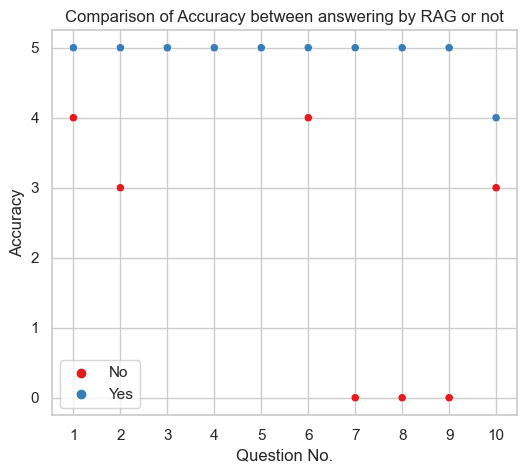

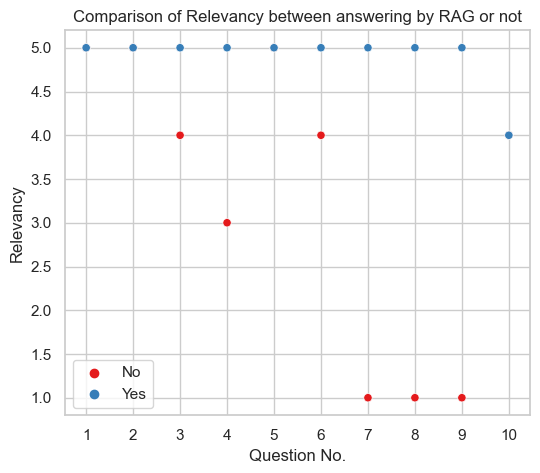

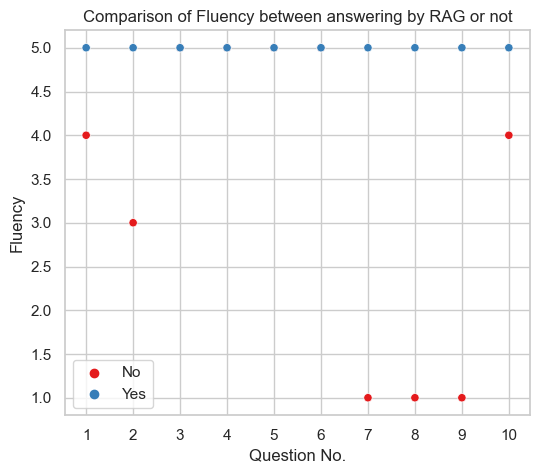

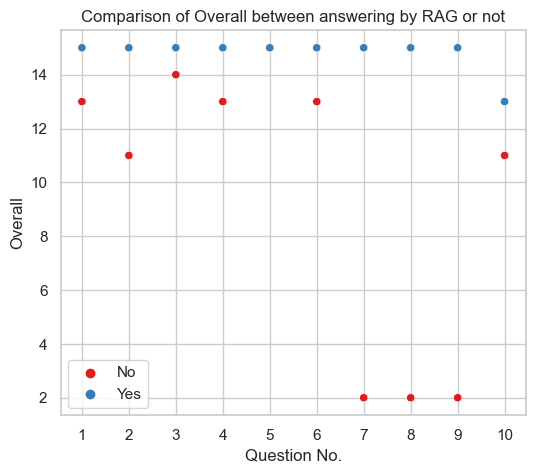

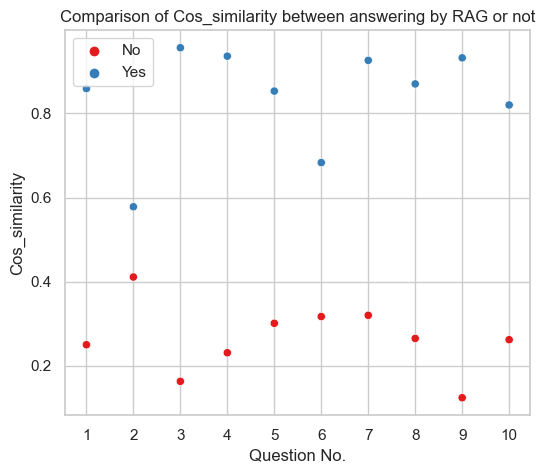

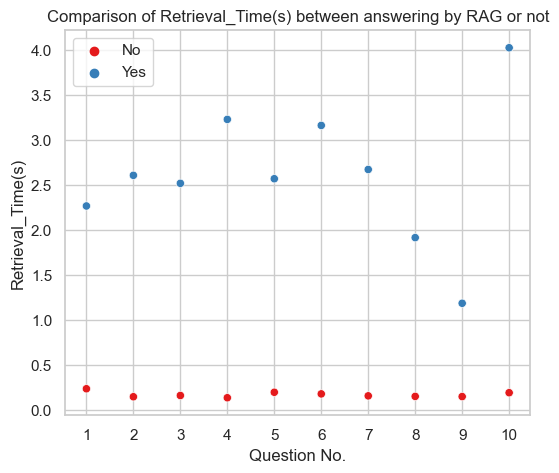

In [53]:
# for each question, plot the 'Accuracy', 'Relevancy', 'Fluency ', 'Overall', 'Cos similarity' between 'answerbyRAG' (yes vs no)
# label the legend as 'RAG', 'no_RAG'


for i in ['Accuracy', 'Relevancy', 'Fluency',
       'Overall', 'Cos_similarity', 'Retrieval_Time(s)']:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x='No.', y=i, hue='RAG_used', data=df, palette='Set1')
    plt.title('Comparison of ' + i + ' between answering by RAG or not')
    plt.xlabel('Question No.')
    plt.legend()
    plt.show()



In [56]:
# calculate the average of 'Overall', 'Cos similarity' for each group of 'answerbyRAG'
# change the col Overall to 'manual_overall'
df['manual_overall'] = df['Overall']
df.groupby('RAG_used')['manual_overall', 'Cos_similarity', 'Retrieval_Time(s)'].mean()




,manual_overall,Cos_similarity,Retrieval_Time(s)
RAG_used,,,
No,9.6,0.2644,0.1715
Yes,14.8,0.8413,2.6187
